In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data[:, [0, 2]]  # Sepal Length (index 0) and Petal Length (index 2)
y = iris.target
# Check the shape of the feature data (X) and target labels (y)
print("Shape of feature data (X):", X.shape)
print("Shape of target labels (y):", y.shape)


Shape of feature data (X): (150, 2)
Shape of target labels (y): (150,)


In [3]:
# Show the first 5 rows of X and y
print("First 5 rows of feature data (X):")
print(X[:5])

print("\nFirst 5 rows of target labels (y):")
print(y[:5])
# Show the first 5 rows of X and y
print("\nlast 5 rows of feature data (X):")
print(X[-5:])

print("\nlast 5 rows of target labels (y):")
print(y[-5:])

First 5 rows of feature data (X):
[[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]]

First 5 rows of target labels (y):
[0 0 0 0 0]

last 5 rows of feature data (X):
[[6.7 5.2]
 [6.3 5. ]
 [6.5 5.2]
 [6.2 5.4]
 [5.9 5.1]]

last 5 rows of target labels (y):
[2 2 2 2 2]


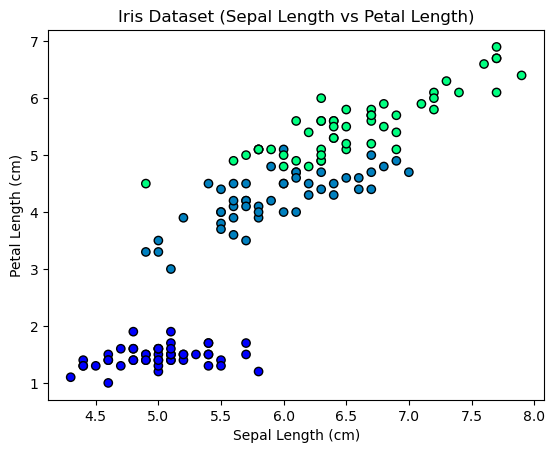

In [4]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k', marker='o')
plt.title("Iris Dataset (Sepal Length vs Petal Length)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.show()

In [5]:
# Split the dataset into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
# Create an SVM classifier with a linear kernel
svm_classifier = SVC(kernel='linear', C=1)

# Train the SVM model
svm_classifier.fit(X_train, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
# Predict on the test data
y_pred = svm_classifier.predict(X_test)

# Classification report and confusion matrix
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


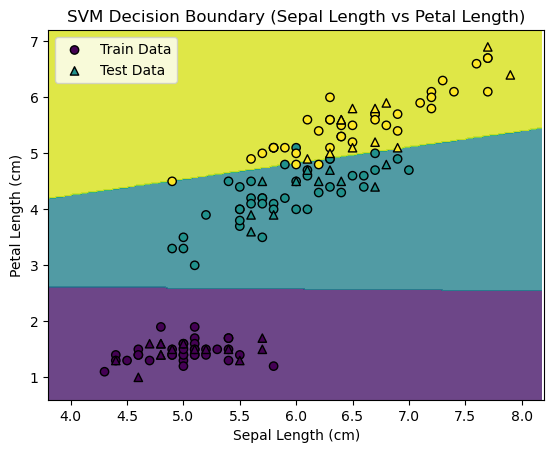

In [9]:
# Plotting the decision boundary (for 2D features)
h = .02  # Step size in the mesh grid, reducing this gives finer resolution
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5  # Slightly reduce the range for zoom effect
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5  # Slightly reduce the range for zoom effect
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on the grid to plot decision boundary
Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary and the training data
plt.contourf(xx, yy, Z, alpha=0.8)  # Color map for the decision regions
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='^', edgecolors='k', label='Test Data')
plt.title("SVM Decision Boundary (Sepal Length vs Petal Length)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend()

# Zooming effect by adjusting axis limits
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()
